In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
from sklearn import neighbors

In [7]:
from matplotlib import colors as c
from sklearn.metrics import classification_report

In [8]:
mydata = pd.read_csv('mydata.csv')
print(mydata.head())

# CA_TOT : 전운량 (대기 구름량)
# HM_AVG : 습도
# RN_DAY : 일 강수량

         TM  CA_TOT  HM_AVG  RN_DAY
0  20150101     3.4    51.1     0.1
1  20150102     3.1    53.6     0.0
2  20150103     3.7    59.6    -9.0
3  20150104     3.1    68.8    -9.0
4  20150105     6.5    79.4     2.0


In [10]:
# 정제
mydata.loc[mydata['RN_DAY'] <= 0, 'RN_DAY'] = 0     # 강수량 0mm 이하를 0으로     << 비 안 옴 >>
mydata.loc[mydata['RN_DAY'] > 0, 'RN_DAY'] = 1      # 강수량 0mm 초과를 1로       << 비 옴 >>
mydata['RN_DAY'] = mydata['RN_DAY'].astype('category') # 강수량 변수 -> 범주형 (변환)
mydata.loc[mydata['CA_TOT'] == -9, 'CA_TOT'] = 0    # 전운량 결측치(-9)를 0으로
mydata.loc[mydata['HM_AVG'] == -9, 'HM_AVG'] = 0    # 습도 결측치(-9)를 0으로

In [23]:
X = mydata[['CA_TOT', 'HM_AVG']]  # 독립변수: 전운량, 습도
y = mydata['RN_DAY']               # 종속변수: 강수량(0=안옴, 1=옴)

In [24]:
print(X.columns)   # X의 컬럼명 출력
print(X.head())    # X 데이터 미리보기

Index(['CA_TOT', 'HM_AVG'], dtype='object')
   CA_TOT  HM_AVG
0     3.4    51.1
1     3.1    53.6
2     3.7    59.6
3     3.1    68.8
4     6.5    79.4


In [25]:
# kNN
kNN = neighbors.KNeighborsClassifier()
kNN.fit(X, y)

KNeighborsClassifier()

In [26]:
# 예측값 산출
Z = kNN.predict(X)

In [27]:
# kNN 결과
target_names = ['0', '1']
print(classification_report(y, Z, target_names = target_names))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       254
           1       0.82      0.76      0.79       111

    accuracy                           0.88       365
   macro avg       0.86      0.84      0.85       365
weighted avg       0.87      0.88      0.88       365



In [28]:
## 도표 설정
plot_step = 0.02

In [29]:
x_min, x_max = X['CA_TOT'].min() - 1, X['CA_TOT'].max() + 1
y_min, y_max = X['HM_AVG'].min() - 1, X['HM_AVG'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))

Z = kNN.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

C:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [31]:
import matplotlib.pyplot as pl

In [32]:
# kNN 결과 반영, 색 입히기
pl.figure(1, figsize = (8, 6))
pl.set_cmap(pl.cm.Paired)

<Figure size 800x600 with 0 Axes>

In [36]:
import matplotlib.pyplot as plt

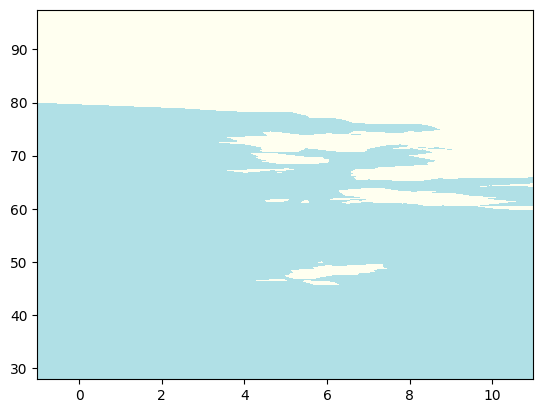

In [33]:
cMap = c.ListedColormap(['powderblue', 'ivory'])
pl.pcolormesh(xx, yy, Z, cmap = cMap)

Text(0, 0.5, 'HM_AVG')

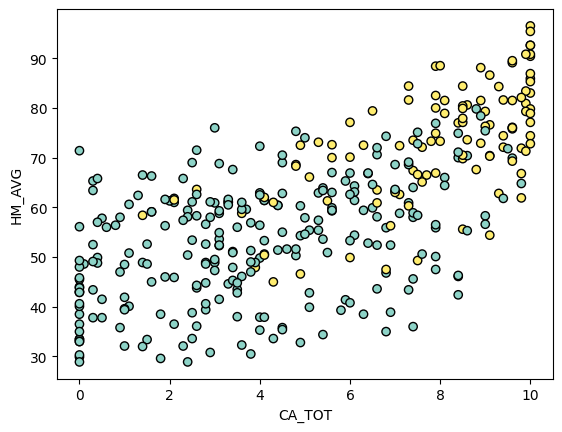

In [37]:
# 독립변수 시각화
plt.scatter(X['CA_TOT'], X['HM_AVG'], c = y, cmap = plt.cm.Set3, edgecolor = 'k')
pl.xlabel('CA_TOT')
pl.ylabel('HM_AVG')

Text(0.5, 1.0, 'Decision Boundary')

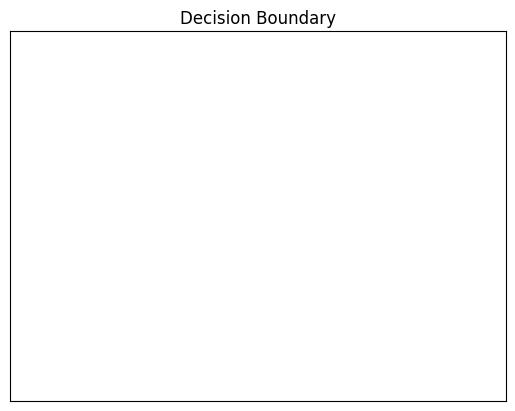

In [38]:
# 축 이름, 도포명
pl.xlim(xx.min(), xx.max())
pl.ylim(yy.min(), yy.max())
pl.xticks(())
pl.yticks(())

plt.title('Decision Boundary')

In [40]:
kNN = neighbors.KNeighborsClassifier(n_neighbors=3)
kNN.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

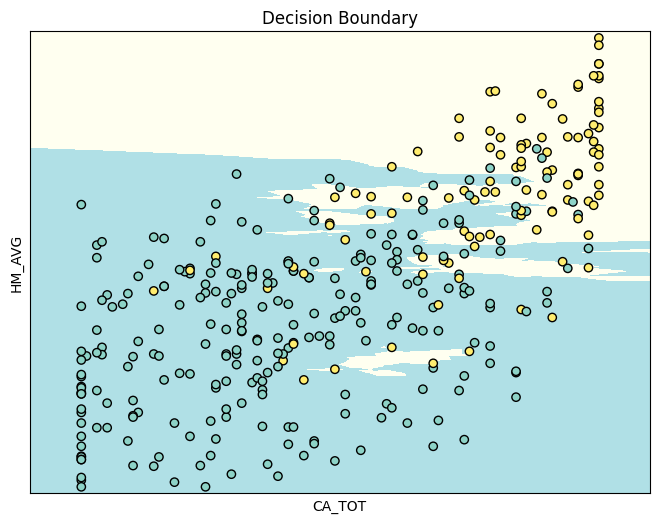

In [41]:
import matplotlib.pyplot as plt
from matplotlib import colors as c

pl = plt  # pl = plt 로 통일

pl.figure(1, figsize=(8, 6))
pl.set_cmap(pl.cm.Paired)

cMap = c.ListedColormap(['powderblue', 'ivory'])

pl.pcolormesh(xx, yy, Z, cmap=cMap)

plt.scatter(X['CA_TOT'], X['HM_AVG'], c=y, cmap=plt.cm.Set3, edgecolor='k')
pl.xlabel('CA_TOT')
pl.ylabel('HM_AVG')

pl.xlim(xx.min(), xx.max())
pl.ylim(yy.min(), yy.max())
pl.xticks(())
pl.yticks(())
plt.title('Decision Boundary')
plt.show()